In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import re 
import statsmodels.api as sm
from scipy import stats
from statsmodels.stats.diagnostic import lilliefors
import seaborn as sns
import numpy as np
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.stattools import jarque_bera
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
# from pmdarima import auto_arima
from math import sqrt
from sklearn.linear_model import LinearRegression


# Data Cleaning

In [2]:
df = pd.read_excel("/Users/nisargpatel/Desktop/University of Niagara Falls/ACADEMICS/Term-2/DAMO-511-16-Data Analytics Case Study-2/Project/Datasets/Medical Equipment Technology Dependence/report (1).xlsx")

df.columns = df.iloc[0]
df = df.iloc[1:].reset_index(drop=True)

# Keep only rows with numeric Value ($)
df = df[df["Value ($)"].notna()].copy()
df["Value ($)"] = pd.to_numeric(df["Value ($)"], errors="coerce")

# Parse Period into proper datetime
df["Period"] = pd.to_datetime(df["Period"], errors="coerce")
df = df[df["Period"].notna()].copy()


print("Data after cleaning:")
print(df[["Period", "Province", "Country", "Value ($)"]].head())


# USA + MEXICO SHARE PER MONTH

# Aggregate total imports per month 
totals = df.groupby("Period")["Value ($)"].sum().rename("Total").reset_index()

# Aggregate USA + Mexico imports per month
na = (
    df[df["Country"].isin(["United States", "Mexico"])]
    .groupby("Period")["Value ($)"]
    .sum()
    .rename("NA")
    .reset_index()
)

# Merge and compute USA+Mexic0 share (% of total)
merged = totals.merge(na, on="Period", how="left")
merged["NA"] = merged["NA"].fillna(0)  

merged["NA_share"] = merged["NA"] / merged["Total"] * 100  

print("\nFirst few rows of monthly USA+Mexico share:")
print(merged[["Period", "Total", "NA", "NA_share"]].head())

print("\nDescriptive stats for USA+Mexico_share (%):")
print(merged["NA_share"].describe())



Data after cleaning:
0     Period Province Country  Value ($)
0 2015-04-01  Ontario  Canada      11128
1 2015-09-01  Ontario  Canada      20240
2 2017-03-01  Ontario  Canada      87654
3 2017-10-01  Ontario  Canada      52906
4 2018-11-01  Ontario  Canada      27437

First few rows of monthly USA+Mexico share:
      Period     Total        NA   NA_share
0 2015-01-01  50946483  35526838  69.733642
1 2015-02-01  46036252  31820079  69.119613
2 2015-03-01  56291236  37738370  67.041289
3 2015-04-01  53216741  35435740  66.587580
4 2015-05-01  53627820  35935095  67.008308

Descriptive stats for USA+Mexico_share (%):
count    109.000000
mean      65.198605
std        4.843203
min       41.158956
25%       62.987952
50%       65.405576
75%       68.201120
max       75.137194
Name: NA_share, dtype: float64


# One-Sample T-Test

In [3]:
# ONE-SAMPLE T-TEST vs 30% SAFETY THRESHOLD
threshold = 30.0  # 30% safety threshold
x = merged["NA_share"].dropna().values

n = len(x)
mean_share = x.mean()
std_share = x.std(ddof=1)
se_share = std_share / np.sqrt(n)
t_stat = (mean_share - threshold) / se_share

print("\n--- ONE-SAMPLE TEST: USA+Mexico_share vs 30% ---")
print(f"n (months)       : {n}")
print(f"Mean NA share    : {mean_share:.2f}")
print(f"Std dev          : {std_share:.4f}")
print(f"Standard error   : {se_share:.4f}")
print(f"t-statistic      : {t_stat:.2f}")
print("Rule of thumb: t > 1.66 ⇒ significant at ~5% (one-sided)")



--- ONE-SAMPLE TEST: USA+Mexico_share vs 30% ---
n (months)       : 109
Mean NA share    : 65.20
Std dev          : 4.8432
Standard error   : 0.4639
t-statistic      : 75.88
Rule of thumb: t > 1.66 ⇒ significant at ~5% (one-sided)


# HHI (Herfindahl–Hirschman Index)

In [4]:
# HHI (HERFINDAHL–HIRSCHMAN INDEX)
# For each month, compute each country's share of total imports, then HHI = sum(share^2)
def compute_hhi(group):
    total = group["Value ($)"].sum()
    shares = group["Value ($)"] / total
    return (shares ** 2).sum()

hhi_per_month = df.groupby("Period").apply(compute_hhi).rename("HHI").reset_index()

print("\n--- HHI (Herfindahl–Hirschman Index) across all suppliers ---")
print(hhi_per_month["HHI"].describe())
print("Interpretation guide (rough): Check Mean - Here 0.081")
print("  < 0.15  → unconcentrated")
print("  0.15–0.25 → moderately concentrated")
print("  > 0.25  → highly concentrated")


--- HHI (Herfindahl–Hirschman Index) across all suppliers ---
count    109.000000
mean       0.081400
std        0.015360
min        0.053303
25%        0.069945
50%        0.078923
75%        0.091521
max        0.147846
Name: HHI, dtype: float64
Interpretation guide (rough): Check Mean - Here 0.081
  < 0.15  → unconcentrated
  0.15–0.25 → moderately concentrated
  > 0.25  → highly concentrated


/var/folders/wy/vbqxm25x54s7tyy0gby30zyw0000gn/T/ipykernel_48067/229253587.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  hhi_per_month = df.groupby("Period").apply(compute_hhi).rename("HHI").reset_index()


# Linear Trend

In [5]:
# TREND IN USA+MEXICO SHARE OVER TIME
# Sort by Period to ensure correct time order
merged_sorted = merged.sort_values("Period").reset_index(drop=True)

# Numeric time index: months since first period
merged_sorted["t"] = np.arange(len(merged_sorted)) 

X = merged_sorted["t"].values.reshape(-1, 1)
y = merged_sorted["NA_share"].values

model = LinearRegression()
model.fit(X, y)

slope_per_month = model.coef_[0]             
intercept = model.intercept_
r_squared = model.score(X, y)

slope_per_year = slope_per_month * 12  

print("\n--- LINEAR TREND IN NA_share OVER TIME ---")
print(f"Slope per month  : {slope_per_month:.5f} (percentage points/month)")
print(f"Slope per year   : {slope_per_year:.5f} (percentage points/year)")
print(f"R-squared        : {r_squared:.3f}")


--- LINEAR TREND IN NA_share OVER TIME ---
Slope per month  : -0.08241 (percentage points/month)
Slope per year   : -0.98892 (percentage points/year)
R-squared        : 0.289


# Visualisation

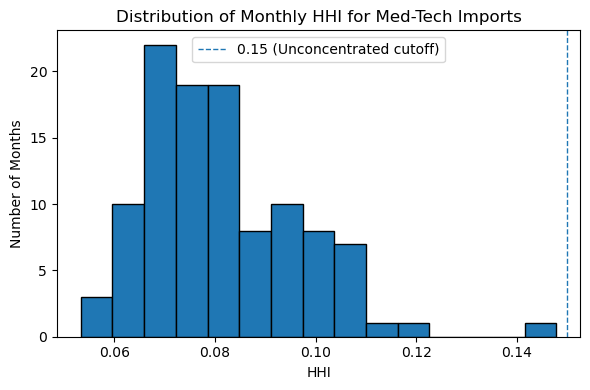

In [6]:

# hhi_per_month has columns: Period, HHI
plt.figure(figsize=(6, 4))
plt.hist(hhi_per_month['HHI'], bins=15, edgecolor='black')

plt.axvline(0.15, linestyle='--', linewidth=1, label='0.15 (Unconcentrated cutoff)')
plt.title("Distribution of Monthly HHI for Med-Tech Imports")
plt.xlabel("HHI")
plt.ylabel("Number of Months")
plt.legend()
plt.tight_layout()
plt.show()
